# Data Association
## Seemingly random plot
https://oeis.org/A133058

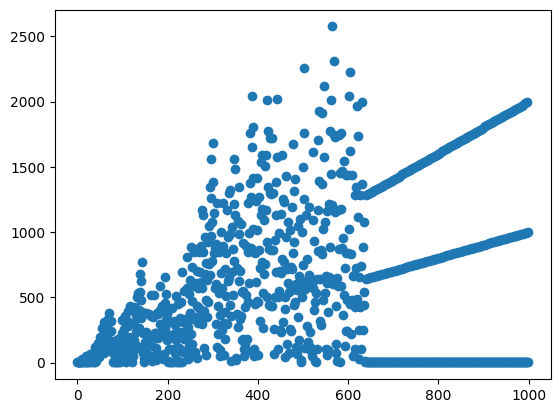

In [29]:
import functools
import numpy as np
import matplotlib.pyplot as plt

@functools.lru_cache # For recursive caching
def f(n):
    if n == 1 or n == 0:
        return 1
    prev = f(n-1)
    div = np.gcd(n, prev)
    if div == 1:
        return prev + n + 1
    else:
        return prev // div
fig, ax = plt.subplots()
x = np.arange(1000)
ax.scatter(x, [f(i) for i in x])
plt.show()

## Variation

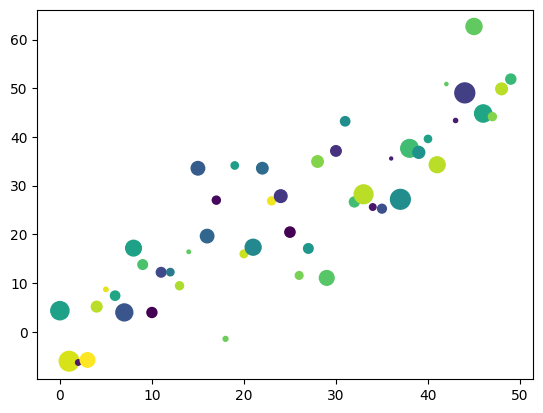

In [12]:
import numpy as np
import matplotlib.pyplot as plt
data = {
    'x' : np.arange(50),
    'y' : np.arange(50) + 10 * np.random.randn(50),
    'color' : np.random.randint(0, 50, 50),
    'size' : np.abs(np.random.randn(50)) * 100,
}
fig, ax = plt.subplots()
ax.scatter('x', 'y', c='color', s='size', data=data)
plt.show()

## Exercise
1. show data using scatter plot
2. draw the average sales line

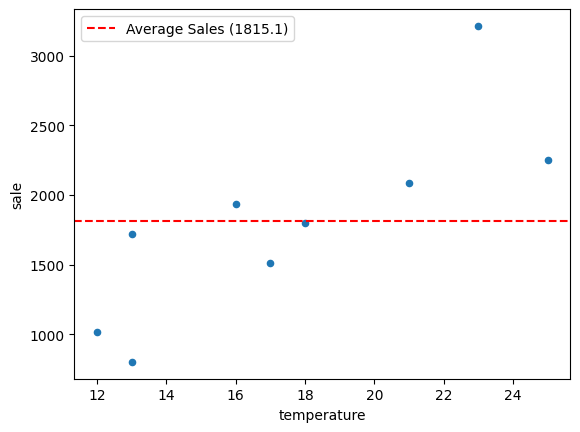

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw = pd.read_csv('./dataset.csv')
ax = raw.plot(kind='scatter', x='temperature', y='sale') # Q1

avg_sales = np.average(raw['sale'])
plt.axhline(y=avg_sales, color='red', linestyle='--',
            label=f'Average Sales ({avg_sales:.1f})') # Q2

plt.legend()
plt.show()

# Line fitting

In [37]:
import numpy as np
import matplotlib.pyplot as plt
def get_line(x, y):
    mean_x = np.average(x)
    mean_y = np.average(y)
    numerator, denominator = 0, 0
    for xi, yi in zip(x, y):
        numerator += (xi - mean_x) * (yi - mean_y)
        denominator += (xi - mean_x) ** 2
    m = numerator / denominator
    b = mean_y - m * mean_x
    return m, b

x = np.random.randint(-50, 50, 50)
y = np.random.randint(-50, 50, 50)
print(get_line(x, y))

(np.float64(-0.0074941327508842095), np.float64(2.5206651375027187))


123.42451612903228 -351.67483870967794


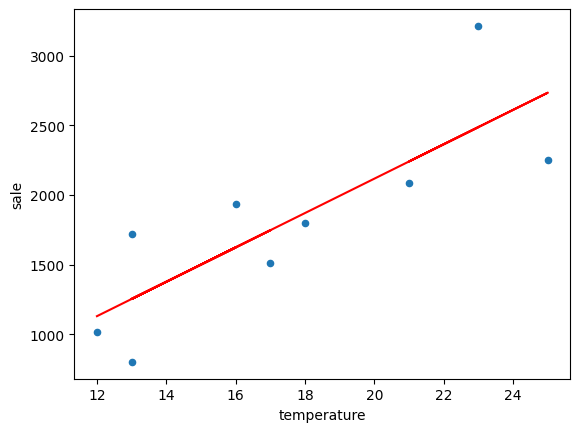

In [61]:
import pandas as pd
raw = pd.read_csv('./dataset.csv')
ax = raw.plot(kind='scatter', x='temperature', y='sale')
temp = raw['temperature']
sale = raw['sale']
m, b = get_line(temp, sale)
# m, b = np.polyfit(temp, sale, 1) # in-built method
print(m, b)
ax.plot(temp, m * temp + b, 'Red')

## Extra (2nd degree curve fitting)
c2, c1, c0 = np.polyfit(temp, sale, 2)
eq_x = np.linspace(temp.min(), temp.max(), 500)
eq_y = c2 * np.power(eq_x, 2) + c1 * eq_x + c0
# ax.plot(eq_x, eq_y, 'Green')

## Extra (3rd degree curve fitting)
c3, c2, c1, c0 = np.polyfit(temp, sale, 3)
eq_x = np.linspace(temp.min(), temp.max(), 500)
eq_y = c3 * np.power(eq_x, 3) + c2 * np.power(eq_x, 2) + c1 * eq_x + c0
# ax.plot(eq_x, eq_y, 'Blue')

plt.show()